In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
from mpl_toolkits.axes_grid1 import inset_locator


# GoDurham - Result & Spatial Analysis
 With the completed bus stop inventory and Bayesian model predictions, this section explores the data from four perspectives to better understand infrastructure conditions, equity, and cleaning priorities:


1. Infrastructure Inventory – Provides an overview of the existing bus stop infrastructure through descriptive statistics, frequency distributions, and spatial visualization of amenities across the network.
2. Equity Analysis – Evaluates whether transit infrastructure aligns with rider demand by constructing an Infrastructure Demand Index and identifying census tracts that may be relatively underserved.
3. Cleaning Priority Results – Visualizes the model-predicted cleaning need and proposed cleaning tiers, illustrating their spatial distribution across the GoDurham network.
4. Current vs. Proposed Cleaning Priorities – Compares the existing cleaning schedule with the Bayesian model recommendations through:
    * Tier reclassification: agreement and disagreement between the current and proposed cleaning tiers.
    * Characteristics of reclassified stops: comparison of ridership, complaints, infrastructure coverage, and predicted cleaning need across reclassified groups.
    * Highest- and lowest-priority bus stops: spatial visualization of the top 10 and bottom 10 stops ranked by predicted cleaning need.
Goal. This report summarizes the 2026 GoDurham bus stop inventory, develops an equity-based infrastructure demand metric, and presents Bayesian model predictions for cleaning priority. The objective is to identify bus stops and communities that may benefit from revised maintenance allocation.

# 1. Data Import

## 1.1 Complete Inventory data (with cleaning score)

In [ ]:
inventory = gpd.read_file("../GoDurham_bus_stops_26917.gpkg")

## 1.2 Census Data (ACS)

In [ ]:
tract = gpd.read_file("../2024_census_acs_dropna_26917.gpkg")

## 1.3 Spatial Join 

In [4]:
# sjoin census tract with the inventory 
inventory_tract = inventory.sjoin(tract,how="inner",predicate="within")

In [5]:
# Dataset summary
summary = pd.DataFrame({
    "Dataset": [
        "2026 Bus Stop Inventory",
        "Census Tracts",
        "Final Analysis Dataset"
    ],
    "Description": [
        "Audited bus stop infrastructure",
        "ACS demographic boundaries",
        "Bus stops joined with census attributes"
    ],
    "Records": [
        len(inventory),
        len(tract),
        len(inventory_tract)
    ],
    "Variables": [
        inventory.shape[1],
        tract.shape[1],
        inventory_tract.shape[1]
    ]
})

summary.set_index("Dataset")

,Description,Records,Variables
Dataset,,,
2026 Bus Stop Inventory,Audited bus stop infrastructure,831,36
Census Tracts,ACS demographic boundaries,65,56
Final Analysis Dataset,Bus stops joined with census attributes,803,92


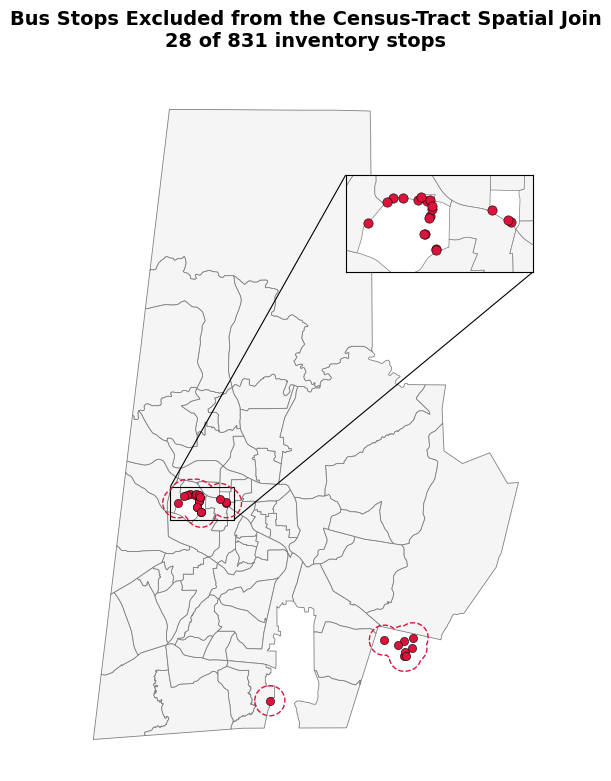

In [6]:

# 1. Find stops excluded from the spatial join

lost = inventory[
    ~inventory["stop_code"].isin(inventory_tract["stop_code"])
].copy()

# Use a projected CRS so buffer distance is in meters
lost = lost.to_crs(26917)
tract_plot = tract.to_crs(26917)


# 2. Create a 1,000-meter buffer around excluded stops

lost_buffer = lost.buffer(1000)

buffer_gdf = gpd.GeoDataFrame(
    geometry=[lost_buffer.union_all()],
    crs=lost.crs
)


# 3. Main figure

fig, ax = plt.subplots(figsize=(9, 9))

# Census tracts
tract_plot.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.6,
    zorder=1
)

# Buffer boundary
buffer_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="crimson",
    linewidth=1,
    linestyle="--",
    zorder=2
)

# Excluded stops
lost.plot(
    ax=ax,
    color="crimson",
    markersize=35,
    edgecolor="black",
    linewidth=0.4,
    zorder=3
)
# Inset

# Downtown cluster only
downtown = lost[

    (lost.geometry.x < 692000) &

    (lost.geometry.y > 3984000)

].copy()

iax = inset_locator.inset_axes(
    ax,
    width="40%",
    height="40%",
    loc="upper right",
    axes_kwargs={"xticks": [], "yticks": []}
)

# Plot context
tract_plot.plot(
    ax=iax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.5
)

downtown.plot(
    ax=iax,
    color="crimson",
    markersize=45,
    edgecolor="black",
    linewidth=0.4
)

# Zoom around downtown points
minx, miny, maxx, maxy = downtown.total_bounds
pad = 500  # meters

iax.set_xlim(minx - pad, maxx + pad)
iax.set_ylim(miny - pad, maxy + pad)

# Draw the inset box
inset_locator.mark_inset(
    ax,
    iax,
    loc1=2,
    loc2=4,
    edgecolor="black",
    linewidth=0.8
)


# 5. Formatting

ax.set_title(
    f"Bus Stops Excluded from the Census-Tract Spatial Join\n"
    f"{len(lost)} of {len(inventory)} inventory stops",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

plt.show()

In [ ]:
# development tier data import
development = gpd.read_file("../OpenData_DevelopmentTiers/Land_Development_-7178204950571489175/Development_Tiers.shp")
development = development.to_crs(26917)

# 2. Infrastucture Analysis (High level overview of bus stop assets)

## 2.1 Bus stop amenities - frequency table

In [8]:
# understand the number 
infra_count = ["shelter_count","bench_count","trash_can_count"]
invetory_infra_count = inventory[infra_count].rename(columns={
    "shelter_count":"shelter",
    "bench_count":"bench",
    "trash_can_count":"trash_can"
})

# understand coverage <-> at least one 
infra_coverage = ["shelter_present", "bench_present","trash_can_present"]
invetory_infra_coverage = inventory[infra_coverage].rename(columns={
    "shelter_present":"shelter",
    "bench_present":"bench",
    "trash_can_present":"trash_can"
})

# agg table 
agg_infra = pd.DataFrame({"Infrastructure Coverage":invetory_infra_coverage.sum(),
                          "Infrastructure Number":invetory_infra_count.sum(),
                          "Infrastructure Coverage Rate": invetory_infra_coverage.sum()/(invetory_infra_coverage.shape)[0]})

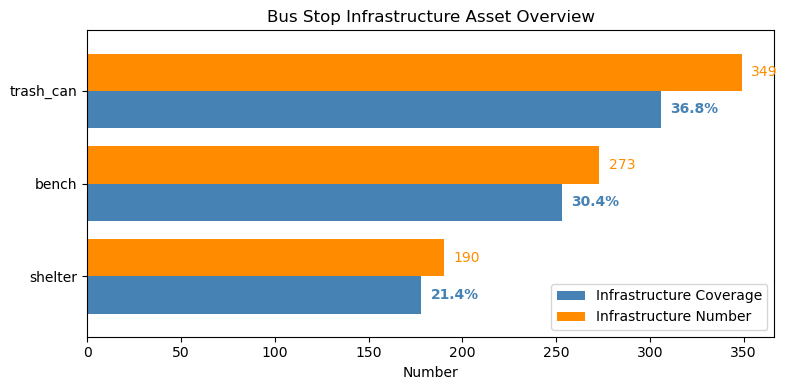

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

# Plot grouped horizontal bars
agg_infra[["Infrastructure Coverage", "Infrastructure Number"]].plot(
    kind="barh",
    ax=ax,
    width=0.8,
    color=["steelblue", "darkorange"]
)

# Annotate coverage rate on the coverage bars
for i, (coverage, rate) in enumerate(
    zip(
        agg_infra["Infrastructure Coverage"],
        agg_infra["Infrastructure Coverage Rate"]
    )
):
    # Coverage bar is the first bar in each group
    ax.text(
        coverage + 5,          # position slightly right of bar
        i - 0.2,               # align with coverage bar
        f"{rate:.1%}",         # e.g. 21.4%
        va="center",
        fontsize=10,
        color="steelblue",
        fontweight="bold"
    )

# Annotate total counts
for i, count in enumerate(agg_infra["Infrastructure Number"]):
    ax.text(
        count + 5,
        i + 0.2,               # align with count bar
        f"{count}",
        va="center",
        fontsize=10,
        color="darkorange"
    )

ax.set_xlabel("Number")
ax.set_ylabel("")
ax.set_title("Bus Stop Infrastructure Asset Overview")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

This Figure shows the basic infrastructure (trash can, bench, and shelter) that bus stop in the city of Durham has, including both the count & coverage among 831 valid bus stops in our final inventory. 

## 2.2 Infrastructure distribution across census tract

In [10]:
# group by census tract and see the coverage rate across those
infra_census = inventory_tract.groupby("GEOID")[["shelter_present","bench_present","trash_can_present"]].mean()

#geometry from tract
tract_geometry = tract[["GEOID","geometry"]]

#spatial join
infra_census_gdf = tract_geometry.merge(infra_census,on="GEOID")

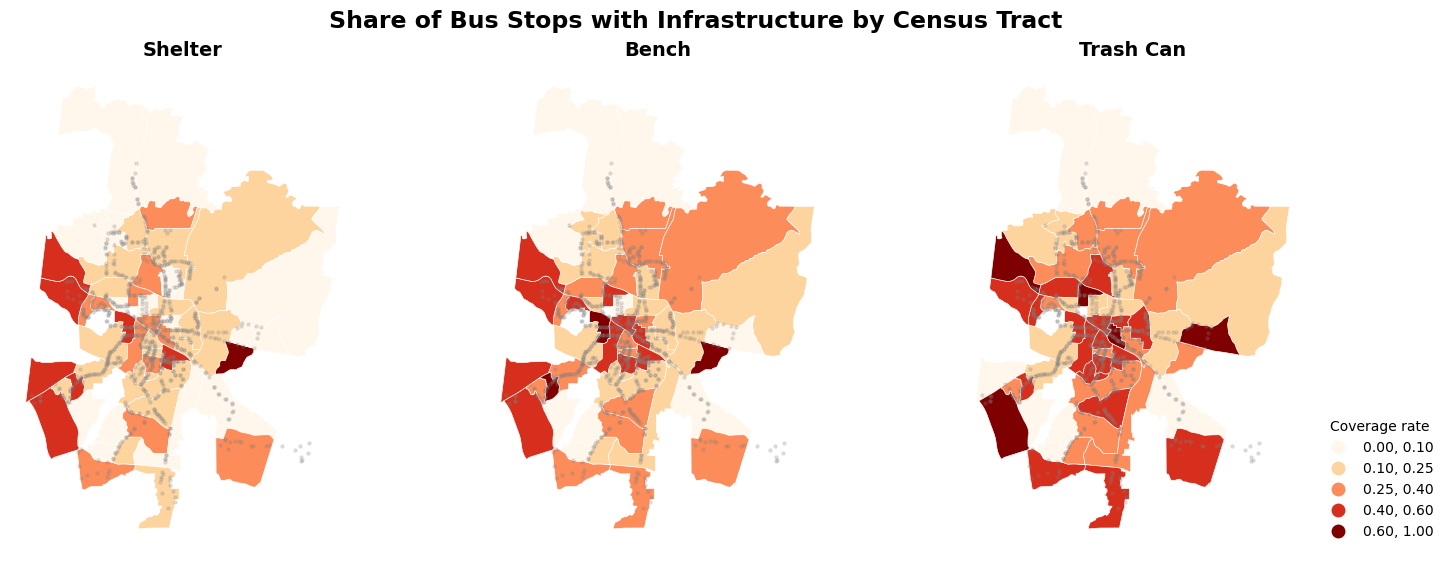

In [11]:
bins = [0.10, 0.25, 0.40, 0.60, 1.00]

columns = [
    "shelter_present",
    "bench_present",
    "trash_can_present"
]

titles = [
    "Shelter",
    "Bench",
    "Trash Can"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5.5),
    constrained_layout=True
)

for i, (ax, column, title) in enumerate(zip(axes, columns, titles)):

    infra_census_gdf.plot(
        ax=ax,
        column=column,
        scheme="user_defined",
        classification_kwds={"bins": bins},
        cmap="OrRd",
        edgecolor="white",
        linewidth=0.45,
        legend=(i == 2),
        legend_kwds={
            "title": "Coverage rate",
            "loc": "lower left",
            "bbox_to_anchor": (1.02, 0),
            "frameon": False
        }
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_axis_off()

for axis in axes:
    inventory.plot(ax=axis,
                markersize=5,
                color="grey",
                alpha=0.2)

fig.suptitle(
    "Share of Bus Stops with Infrastructure by Census Tract",
    fontsize=17,
    fontweight="bold"
)

plt.show()

# 3. Equity Analysis (Which communities, if any, are being underserved?)

In [12]:
Equity = inventory_tract.copy()

Equity["shelter_count_norm"] = Equity["shelter_count"].apply(lambda x: (x- min(Equity["shelter_count"]))/(max(Equity["shelter_count"])-min(Equity["shelter_count"])))

Equity["bench_count_norm"] = Equity["bench_count"].apply(lambda x:(x- min(Equity["bench_count"]))/(max(Equity["bench_count"])-min(Equity["bench_count"])))

Equity["trash_can_count_norm"]  = Equity["trash_can_count"].apply(lambda x:(x- min(Equity["trash_can_count"]))/(max(Equity["trash_can_count"])-min(Equity["trash_can_count"])))

Equity["ridership_norm"] = (
    (Equity["average_daily_ridership"] - Equity["average_daily_ridership"].min())
    /
    (Equity["average_daily_ridership"].max() - Equity["average_daily_ridership"].min())
)

# assigning weight - need more evidence tho
Equity["Amentiy Score"] = 0.5* Equity["shelter_count_norm"] +0.3* Equity["bench_count_norm"]+ 0.2* Equity["trash_can_count_norm"] 

In [13]:
#Need score is proportional to ridership but proportional to (1-Amenity score)
Equity["Infrastructure Demand Index"] = (1-Equity["Amentiy Score"])*Equity["ridership_norm"]

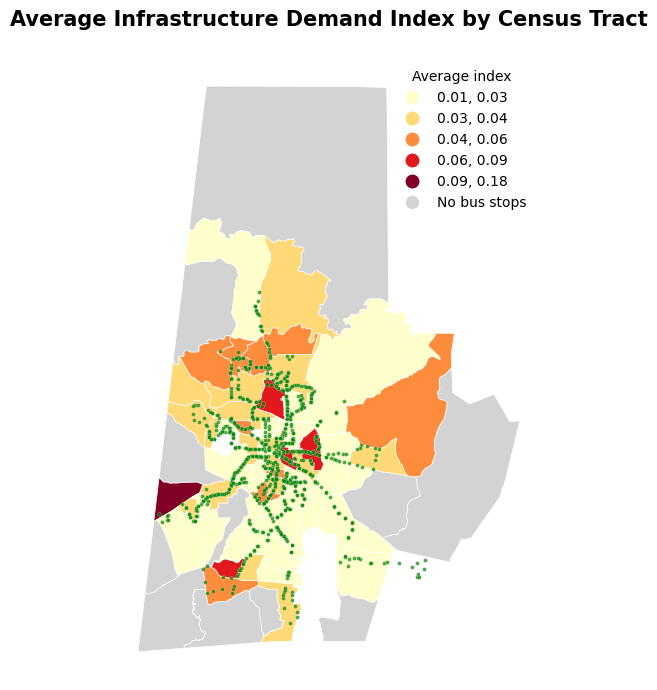

In [14]:
# Aggregate stop-level demand to the census-tract level
need_score_census = (
    Equity
    .groupby("GEOID", as_index=False)
    .agg(
        avg_infrastructure_demand=("Infrastructure Demand Index", "mean"),
        total_infrastructure_demand=("Infrastructure Demand Index", "sum"),
        number_of_stops=("Infrastructure Demand Index", "size")
    )
)

# Join tract-level results to census tract geometry
need_score_census_gdf = tract_geometry.merge(
    need_score_census,
    on="GEOID",
    how="left"
)

fig, ax = plt.subplots(figsize=(8, 7))

# 1. Census tract demand layer — background
need_score_census_gdf.plot(
    ax=ax,
    column="avg_infrastructure_demand",
    cmap="YlOrRd",
    scheme="natural_breaks",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No bus stops"
    },
    legend_kwds={
        "title": "Average index",
        "loc": "upper right",
        "frameon": False
    },
    zorder=1
)


# 3. Bus-stop points — draw on top
inventory.plot(
    ax=ax,
    markersize=8,
    color="green",
    alpha=0.7,
    edgecolor="white",
    linewidth=0.2,
    zorder=2
)

ax.set_title(
    "Average Infrastructure Demand Index by Census Tract",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

To estimate infrastructure demand at the census tract level, amenity features (shelters, benches, and trash cans) were first normalized using min–max scaling. A composite Amenity Score was then computed as a weighted combination of these normalized variables. Next, an Infrastructure Demand Index was calculated by multiplying the complement of the Amenity Score, (1-Amenity Score), by normalized average daily ridership. This index identifies locations where high transit demand coincides with relatively limited infrastructure. Finally, the stop-level Infrastructure Demand Index was averaged within each census tract to identify communities whose bus stops are, on average, the most underserved.

In [15]:
need_score_census_gdf = need_score_census_gdf.sort_values("avg_infrastructure_demand",ascending=False)

Top5 = need_score_census_gdf["GEOID"].iloc[:5].to_list()

print (f"Top five communities that exhibit relatively high avg infrastructure demand are: {Top5}")


Top five communities that exhibit relatively high avg infrastructure demand are: ['37063002029', '37063001100', '37063002023', '37063000102', '37063001002']


# 4.Cleaning Priority Score Result

Tier 1 (90–100th percentile): Critical Priority

Tier 2 (75–90th percentile): High Priority

Tier 3 (50–75th percentile): Moderate Priority

Tier 4 (0–50th percentile): Routine Priority

## 4.1 Spatial plot of predicted cleaning score & cleaning tier (1-4 Tier)

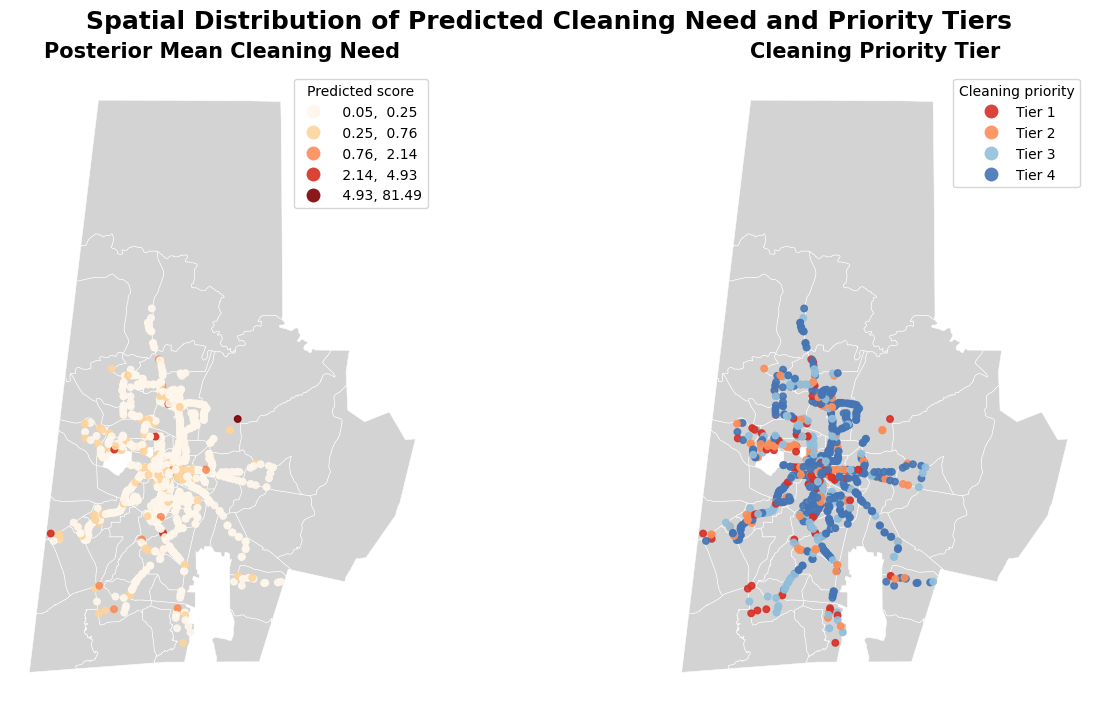

In [16]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(
    1, 2,
    figsize=(13, 7),
    constrained_layout=True
)

# Base census-tract map
for axis in ax:
    tract.plot(
        ax=axis,
        facecolor="lightgrey",
        edgecolor="white",
        linewidth=0.4
    )


# 1. Predicted cleaning score

inventory_tract.plot(
    ax=ax[0],
    column="predicted_cleaning_need",
    cmap="OrRd",
    scheme="natural_breaks",
    k=5,
    markersize=22,
    alpha=0.9,
    legend=True,
    legend_kwds={
        "title": "Predicted score",
        "loc": "upper right",
        "frameon": True
    }
)

ax[0].set_title(
    "Posterior Mean Cleaning Need",
    fontsize=15,
    fontweight="bold",
    pad=10
)

# 2. Cleaning priority tier

tier_order = ["Tier 1", "Tier 2", "Tier 3", "Tier 4"]

inventory_tract["cleaning_need_tier"] = (
    inventory_tract["cleaning_need_tier"]
    .astype("category")
    .cat.reorder_categories(tier_order, ordered=True)
)

tier_cmap = ListedColormap([
    "#d73027",  # Tier 1
    "#fc8d59",  # Tier 2
    "#91bfdb",  # Tier 3
    "#4575b4"   # Tier 4
])

inventory_tract.plot(
    ax=ax[1],
    column="cleaning_need_tier",
    categorical=True,
    cmap=tier_cmap,
    markersize=22,
    alpha=0.9,
    legend=True,
    legend_kwds={
        "title": "Cleaning priority",
        "loc": "upper right",
        "frameon": True
    }
)

ax[1].set_title(
    "Cleaning Priority Tier",
    fontsize=15,
    fontweight="bold",
    pad=10
)


# Final formatting

for axis in ax:
    axis.set_axis_off()
    axis.set_aspect("equal")

fig.suptitle(
    "Spatial Distribution of Predicted Cleaning Need and Priority Tiers",
    fontsize=18,
    fontweight="bold"
)

plt.show()

## 4.2 Comparison between A/B/C Tier (current) and 1-4 Tier (proposed)

### 4.2.1 Tier change

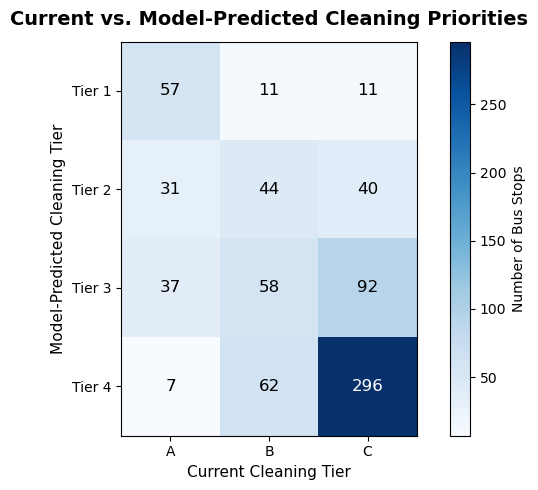

In [17]:
tier_table = pd.crosstab(
    inventory_tract["cleaning_need_tier"],
    inventory_tract["current_cleaning_tier"]
).reindex(
    index=["Tier 1", "Tier 2", "Tier 3", "Tier 4"],
    columns=["A", "B", "C"]
)

fig, ax = plt.subplots(figsize=(7, 5))

image = ax.imshow(tier_table, cmap="Blues")

# Cell labels
for row in range(tier_table.shape[0]):
    for col in range(tier_table.shape[1]):
        value = tier_table.iloc[row, col]

        ax.text(
            col,
            row,
            f"{value}",
            ha="center",
            va="center",
            fontsize=12,
            color="white" if value > tier_table.values.max() / 2 else "black"
        )

ax.set_xticks(range(len(tier_table.columns)))
ax.set_xticklabels(tier_table.columns)

ax.set_yticks(range(len(tier_table.index)))
ax.set_yticklabels(tier_table.index)

ax.set_xlabel("Current Cleaning Tier", fontsize=11)
ax.set_ylabel("Model-Predicted Cleaning Tier", fontsize=11)

ax.set_title(
    "Current vs. Model-Predicted Cleaning Priorities",
    fontsize=14,
    fontweight="bold",
    pad=12
)

fig.colorbar(image, ax=ax, label="Number of Bus Stops")

plt.tight_layout()
plt.show()

This cross-tabulation compares the current cleaning tiers (A–C) assigned by GoDurham with the model-predicted cleaning priority tiers (Tier 1–4). The darker diagonal cells indicate broad agreement between the existing cleaning schedule and the model’s recommendations. Off-diagonal cells represent bus stops that were reclassified by the Bayesian model. These reclassifications reflect information learned from observed bus stop characteristics, census tract–level random effects that capture unobserved neighborhood heterogeneity, and historical complaint data. As a result, the model identifies locations where cleaning priorities may differ from the current operational schedule.

### 4.2.2 Characteristics of Reclassified Bus Stops

In [18]:
summary = (
    inventory_tract
    .groupby(
        ["cleaning_need_tier", "current_cleaning_tier"]
    )
    .agg(
        Stops=("stop_code", "count"),
        Ridership=("average_daily_ridership", "mean"),
        Complaints=("complaint_count", "mean"),
        Shelter=("shelter_present", "mean"),
        Bench=("bench_present", "mean"),
        Trash_Can=("trash_can_present", "mean"),
        Predicted_Need=("predicted_cleaning_need", "mean")
    )
    .round(2)
)

summary

Stops  Ridership  Complaints  \
cleaning_need_tier current_cleaning_tier                                 
Tier 1             A                         57     134.10        1.30   
                   B                         11      64.04        0.27   
                   C                         11      16.65        0.55   
Tier 2             A                         31      54.44        0.16   
                   B                         44      36.79        0.34   
                   C                         40      22.04        0.18   
Tier 3             A                         37      48.50        0.11   
                   B                         58      35.62        0.26   
                   C                         92      17.82        0.12   
Tier 4             A                          7      24.66        0.00   
                   B                         62      19.30        0.19   
                   C                        296       8.13        0.04   

                                          Shelter  Bench  Trash_Can  \
cleaning_need_tier current_cleaning_tier                              
Tier 1             A                         0.84   0.86       0.84   
                   B                         0.82   1.00       0.91   
                   C                         1.00   1.00       0.82   
Tier 2             A                         0.58   0.71       0.87   
                   B                         0.64   0.73       0.64   
                   C                         0.80   0.82       0.78   
Tier 3             A                         0.14   0.32       0.46   
                   B                         0.07   0.29       0.38   
                   C                         0.10   0.28       0.38   
Tier 4             A                         0.00   0.00       0.14   
                   B                         0.00   0.08       0.24   
                   C                         0.00   0.06       0.15   

                                          Predicted_Need  
cleaning_need_tier current_cleaning_tier                  
Tier 1             A                                2.44  
                   B                                0.52  
                   C                                0.47  
Tier 2             A                                0.29  
                   B                                0.28  
                   C                                0.27  
Tier 3             A                                0.17  
                   B                                0.16  
                   C                                0.16  
Tier 4             A                                0.10  
                   B                                0.09  
                   C                                0.09

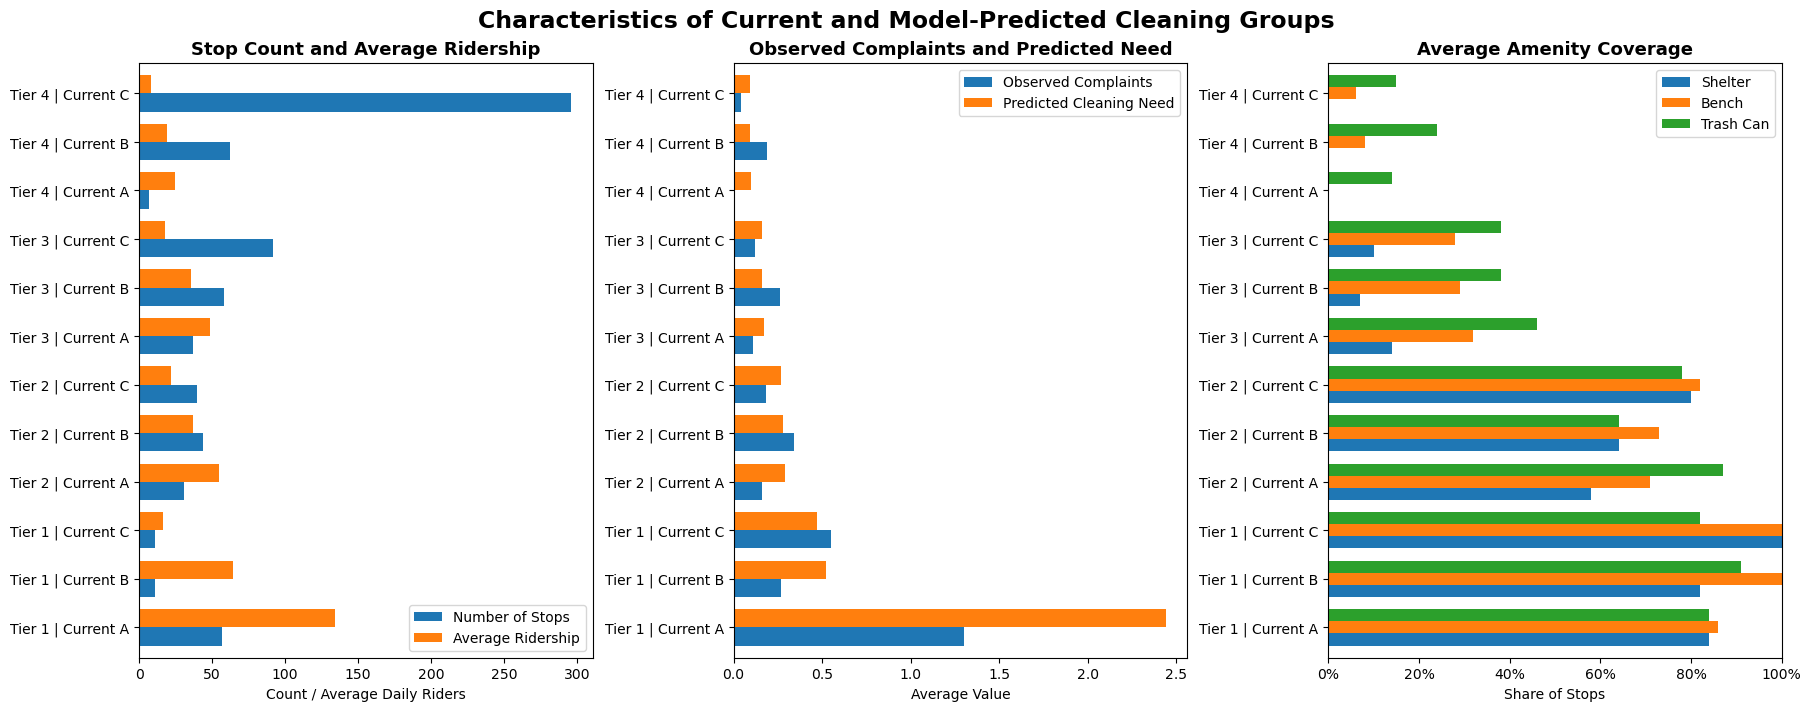

In [19]:
# Keep a readable index
summary_plot = summary.reset_index()

summary_plot["Group"] = (
    summary_plot["cleaning_need_tier"].astype(str)
    + " | Current "
    + summary_plot["current_cleaning_tier"].astype(str)
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 7),
    constrained_layout=True
)


# 1. Group size and ridership

summary_plot.plot(
    x="Group",
    y=["Stops", "Ridership"],
    kind="barh",
    ax=axes[0],
    width=0.75
)

axes[0].set_title(
    "Stop Count and Average Ridership",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_xlabel("Count / Average Daily Riders")
axes[0].set_ylabel("")
axes[0].legend(
    ["Number of Stops", "Average Ridership"],
    title=""
)


# 2. Complaints and predicted need

summary_plot.plot(
    x="Group",
    y=["Complaints", "Predicted_Need"],
    kind="barh",
    ax=axes[1],
    width=0.75
)

axes[1].set_title(
    "Observed Complaints and Predicted Need",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Average Value")
axes[1].set_ylabel("")
axes[1].legend(
    ["Observed Complaints", "Predicted Cleaning Need"],
    title=""
)


# 3. Amenity coverage

summary_plot.plot(
    x="Group",
    y=["Shelter", "Bench", "Trash_Can"],
    kind="barh",
    ax=axes[2],
    width=0.75
)

axes[2].set_title(
    "Average Amenity Coverage",
    fontsize=13,
    fontweight="bold"
)
axes[2].set_xlabel("Share of Stops")
axes[2].set_ylabel("")
axes[2].set_xlim(0, 1)
axes[2].legend(
    ["Shelter", "Bench", "Trash Can"],
    title=""
)

# Format proportions as percentages
axes[2].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

fig.suptitle(
    "Characteristics of Current and Model-Predicted Cleaning Groups",
    fontsize=17,
    fontweight="bold"
)

plt.show()

These three bar charts characterize each subgroup formed by the intersection of the current cleaning tiers (A–C) and the model-predicted cleaning priority tiers (Tier 1–4). The first summarizes operational demand through the number of bus stops and average daily ridership. The second compares historical maintenance demand (observed complaint counts) with the model’s predicted cleaning priority scores. The third compares average infrastructure coverage, including shelters, benches, and trash cans. Collectively, these figures provide insight into why certain bus stops were reclassified by the model while others remained consistent with the existing cleaning schedule.

In [20]:
under_served = inventory_tract[
    (inventory_tract["current_cleaning_tier"] == "C") &
    (inventory_tract["cleaning_need_tier"] == "Tier 1")
]

over_served = inventory_tract[
    (inventory_tract["current_cleaning_tier"] == "A") &
    (inventory_tract["cleaning_need_tier"] == "Tier 4")
]

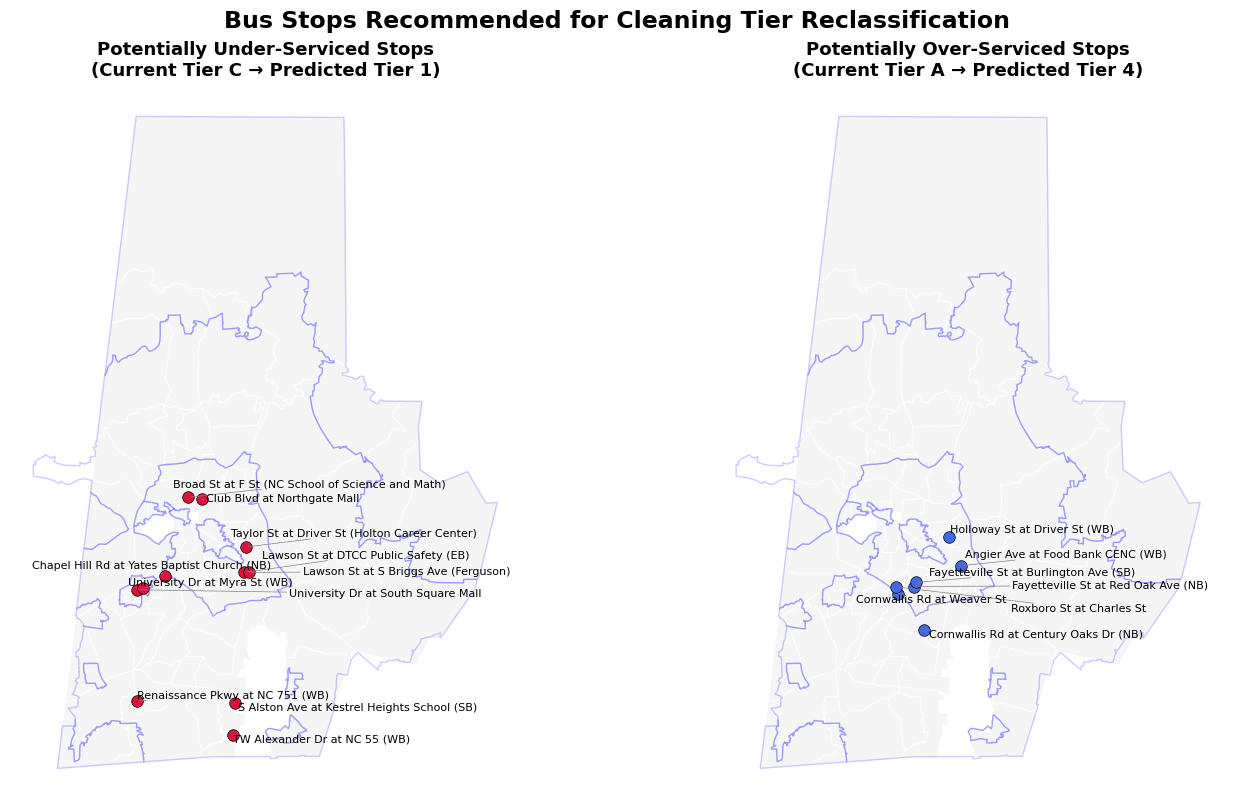

In [21]:

# Select reclassified bus stops


under_served = inventory_tract[
    (inventory_tract["current_cleaning_tier"] == "C") &
    (inventory_tract["cleaning_need_tier"] == "Tier 1")
]

over_served = inventory_tract[
    (inventory_tract["current_cleaning_tier"] == "A") &
    (inventory_tract["cleaning_need_tier"] == "Tier 4")
]


# Create figure

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 8),
    constrained_layout=True
)


# Base map

for axis in ax:

    tract.plot(
        ax=axis,
        facecolor="whitesmoke",
        edgecolor="white",
        linewidth=0.5
    )
    development.plot(
        ax=axis,
        facecolor="none",
        edgecolor="blue",
        alpha=0.2
    )


# Under-serviced stops

under_served.plot(
    ax=ax[0],
    color="crimson",
    markersize=70,
    edgecolor="black",
    linewidth=0.5
)

texts = []

for _, row in under_served.iterrows():
    texts.append(
        ax[0].text(
            row.geometry.x,
            row.geometry.y,
            row["stop_name"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax[0],
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.5
    )

)

ax[0].set_title(
    "Potentially Under-Serviced Stops\n(Current Tier C → Predicted Tier 1)",
    fontsize=13,
    fontweight="bold"
)


# Over-serviced stops

over_served.plot(
    ax=ax[1],
    color="royalblue",
    markersize=70,
    edgecolor="black",
    linewidth=0.5
)

texts = []

for _, row in over_served.iterrows():
    texts.append(
        ax[1].text(
            row.geometry.x,
            row.geometry.y,
            row["stop_name"],
            fontsize=8
        )

    )

adjust_text(

    texts,

    ax=ax[1],

    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.5
    )

)

ax[1].set_title(
    "Potentially Over-Serviced Stops\n(Current Tier A → Predicted Tier 4)",
    fontsize=13,
    fontweight="bold"
)


# Formatting

for axis in ax:
    axis.set_axis_off()

fig.suptitle(
    "Bus Stops Recommended for Cleaning Tier Reclassification",
    fontsize=17,
    fontweight="bold"
)

plt.show()

### 4.2.3 Top 10 and Bottom 10 Bus Stops by Predicted Cleaning Need

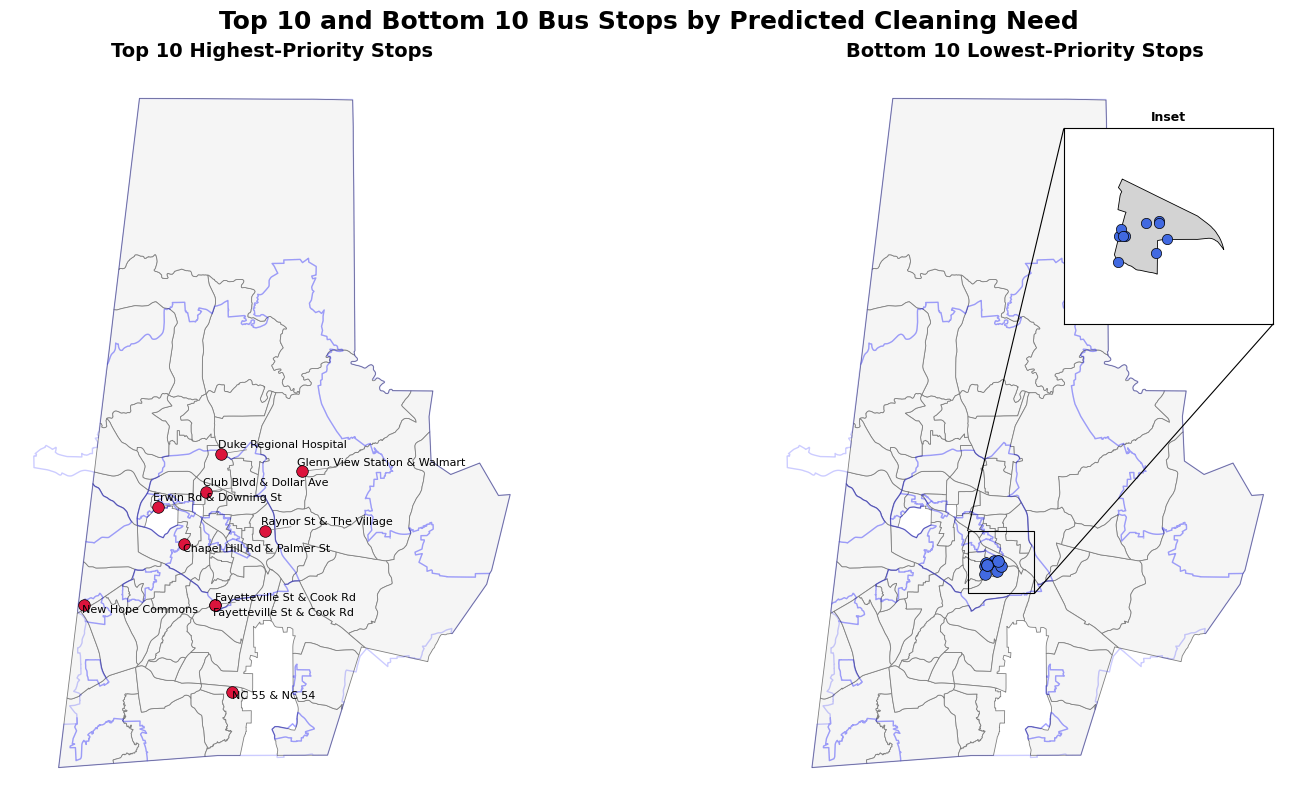

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import inset_locator
from adjustText import adjust_text


# Top 10 and Bottom 10 Bus Stops
 

top10 = (
    inventory_tract
    .sort_values("predicted_cleaning_need", ascending=False)
    .head(10)
    .copy()
)

bottom10 = (
    inventory_tract
    .sort_values("predicted_cleaning_need", ascending=True)
    .head(10)
    .copy()
)


# Ensure common CRS


target_crs = tract.crs

tract_geometry = tract_geometry.to_crs(target_crs)
top10 = top10.to_crs(target_crs)
bottom10 = bottom10.to_crs(target_crs)

bottom10 = bottom10.drop(
    columns=["index_right", "index_left"],
    errors="ignore"
)


# Bottom-10 census tracts (for inset)


bottom_geoids = bottom10["GEOID"].dropna().unique()

bottom_tract = tract_geometry[
    tract_geometry["GEOID"].isin(bottom_geoids)
].copy()


# Shorten stop names


for df in [top10, bottom10]:

    df["short_name"] = (
        df["stop_name"]
        .str.replace(r"\s*\([^)]*\)", "", regex=True)
        .str.replace(" at ", " & ", regex=False)
        .str.slice(0, 28)
    )


# Plot


fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,8),
    constrained_layout=True
)


# Base map


for axis in ax:

    tract.plot(
        ax=axis,
        facecolor="whitesmoke",
        edgecolor="grey",
        linewidth=0.6
    )
    development.plot(
        ax=axis,
        facecolor="None",
        edgecolor="blue",
        alpha=0.2
    )

    axis.set_axis_off()


# Top 10


top10.plot(
    ax=ax[0],
    color="crimson",
    edgecolor="black",
    linewidth=0.5,
    markersize=70,
    zorder=3
)

texts=[]

for _, row in top10.iterrows():
    texts.append(
        ax[0].text(
            row.geometry.x,
            row.geometry.y,
            row["short_name"],
            fontsize=8,
            ha="left",
            va="bottom"
        )
    )

adjust_text(
    texts,
    ax=ax[0],
    arrowprops=dict(
        arrowstyle="-",
        color="grey",
        lw=0.5
    )
)

ax[0].set_title(
    "Top 10 Highest-Priority Stops",
    fontsize=14,
    fontweight="bold"
)

# Bottom 10

bottom10.plot(
    ax=ax[1],
    color="royalblue",
    edgecolor="black",
    linewidth=0.5,
    markersize=70,
    zorder=3
)


ax[1].set_title(
    "Bottom 10 Lowest-Priority Stops",
    fontsize=14,
    fontweight="bold"
)

# Inset map


iax = inset_locator.inset_axes(
    ax[1],
    width="40%",
    height="40%",
    loc="upper right",
    borderpad=1

)

bottom_tract.plot(
    ax=iax,
    facecolor="lightgrey",
    edgecolor="black",
    linewidth=0.6
)

bottom10.plot(
    ax=iax,
    color="royalblue",
    edgecolor="black",
    markersize=55,
    linewidth=0.5
)

minx, miny, maxx, maxy = bottom_tract.total_bounds
padding = 1000

iax.set_xlim(minx-padding,maxx+padding)

iax.set_ylim(miny-padding,maxy+padding)

iax.set_xticks([])

iax.set_yticks([])

iax.set_title(
    "Inset",
    fontsize=9,
    fontweight="bold"

)

inset_locator.mark_inset(
    ax[1],
    iax,
    loc1=2,
    loc2=4,
    linewidth=0.8
)

# Figure title

fig.suptitle(

    "Top 10 and Bottom 10 Bus Stops by Predicted Cleaning Need",

    fontsize=18,

    fontweight="bold"

)

plt.show()

This figure displays the 10 highest- and 10 lowest-priority bus stops based on the model-predicted cleaning need. The inset map provides a closer view of the lowest-priority stops where they are spatially clustered. Together, these maps illustrate the geographic distribution of the model’s recommendations and highlight locations for potential maintenance prioritization and field validation.

# 5. Conclusions

Main findings

* Inventory shows uneven distribution of bus stop amenities.
* Several census tracts exhibit consistently higher infrastructure demand.
* Bayesian predictions generally agree with the existing cleaning schedule but identify meaningful reclassifications.
* The model highlights specific bus stops for potential cleaning priority updates.

Limitations

* Complaint counts may not perfectly reflect cleaning need.
* Amenity weights were selected heuristically.
* Infrastructure Demand Index is descriptive rather than model-based.

Future work

* Incorporate weather and land-use variables.
* Validate recommendations using future cleaning records.
* Optimize maintenance routing under budget constraints.